<a href="https://colab.research.google.com/github/aliradameli/kwave-Breast-Tissue-Modeling/blob/main/Tissue_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [180]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.animation import FuncAnimation
import cv2 as cv
from kwave.kgrid import kWaveGrid
from kwave.kmedium import kWaveMedium
from kwave.ksource import kSource
from kwave.ksensor import kSensor
from kwave.kspaceFirstOrder2D import kspaceFirstOrder2D
from decimal import Decimal

plt.style.use('default')
 

In [181]:
base_rndseed = 40
np.random.seed(base_rndseed)

# define the computational grid
dx = 10e-6 # grid point spacing in the x and y direction [m]
dy = 10e-6 # grid point spacing in the x and y direction [m]
Nx = 1024  # number of grid points in the x direction
Ny = 2*1024   # number of grd points in the y direction

grid = kWaveGrid([Nx, Ny], [dx, dy])
X , Y = np.meshgrid(grid.x_vec, grid.y_vec , indexing='ij')
grid.makeTime(c=1540, t_end=2e-5, cfl=1)


(array([[0.00000000e+00, 6.49350649e-09, 1.29870130e-08, ...,
         1.99870130e-05, 1.99935065e-05, 2.00000000e-05]], shape=(1, 3081)),
 np.float64(6.493506493506494e-09))

In [182]:
class BreastMap:
    def __init__(self, Nx, Ny, dx, dy, rndseed, max_num_tumors=3):
        self.Nx = Nx
        self.Ny = Ny
        self.dx = dx
        self.dy = dy
        self.max_num_tumors = max_num_tumors  # Configuration stored here
        np.random.seed(rndseed)
        # Initialize empty maps
        self.sos_map = np.zeros((Nx, Ny))
        self.rho_map = np.zeros((Nx, Ny))
        # Internal tracking for layers
        self.epi_thickness = 0
        self.total_skin_thickness = 0

    def microns2meters(self, thickness):
        """
        Converts thickness from micrometers (μm) to meters (m).

        Args:
            thickness (float): The thickness in micrometers.

        Returns:
            float: The equivalent thickness in meters.
        """
        return thickness * 1e-6

    def microns2pixels(self, thickness):
        """
        Converts physical thickness from micrometers (μm) to grid pixel units.

        Args:
            thickness (float): The thickness in micrometers (e.g., from the tissue table).

        Returns:
            int: The equivalent number of pixels based on the vertical resolution (dy).
        """
        return int(Decimal(str(thickness)) * Decimal('1e-6') / Decimal(str(self.dy)))

    def addGel(self, var=2.5):
        """
        Simulates a Propylene Glycol coupling gel layer at the beginning of the maps.

        Args:
            var (float): Standard deviation for the Gaussian noise applied to SOS and density.
        """
        gel_thickness = 1

        # Speed-of-Sound (SOS) for Propylene Glycol: sampled from an experimental range [1467.8, 1541.1] m/s
        sos_val = np.random.uniform(1467.805 , 1541.057)

        # Density (Rho) for Propylene Glycol: sampled from range [1036, 1040] kg/m^3
        rho_val = np.random.uniform(1036 , 1040)

        # Apply values to the first 'gel_thickness' columns with added Gaussian noise for heterogeneity
        self.sos_map[:, :gel_thickness] = np.random.normal(sos_val, var, (self.Nx, gel_thickness))
        self.rho_map[:, :gel_thickness] = np.random.normal(rho_val, var, (self.Nx, gel_thickness))

        self.gel_thickness = gel_thickness
        return self

    def addEpidermis(self, var=2.5):
        """
        Simulates the epidermis layer based on biological tissue properties.
        The layer is placed immediately after the coupling gel.

        Args:
            var (float): Internal variance (porosity) to simulate tissue heterogeneity.
        """
        # 1. Randomize layer thickness and acoustic properties from literature ranges
        # Thickness range: ~84.5 to 156.7 um (Ref: Measurement of Epidermis, Dermis, and Total Skin Thicknesses)
        low_h = self.microns2pixels(120.6 - 36.1)
        high_h = self.microns2pixels(120.6 + 36.1)
        epiderm_thickness = np.random.randint(low_h, high_h)

        # Sound Speed (c) and Density (rho) randomized within experimental bounds
        sos_val = np.random.uniform(1531.9, 1735.5)   # Range: 1633.7 ± 101.8 m/s
        rho_val = np.random.uniform(1095.11, 1122.89) # Range: 1109 ± 13.89 kg/m^3

        # 2. Define layer boundaries (starts after the gel layer)
        start = self.gel_thickness
        end = start + epiderm_thickness

        # 3. Populate maps with Gaussian noise to simulate realistic tissue texture
        self.sos_map[:, start:end] = np.random.normal(sos_val, var, (self.Nx, epiderm_thickness))
        self.rho_map[:, start:end] = np.random.normal(rho_val, var, (self.Nx, epiderm_thickness))

        self.epi_thickness = epiderm_thickness
        return self
    #TODO: 
    # def beacon(self)
    def addDermis(self, var=2.5):
        """
        Simulates the dermis layer by placing it after the epidermis.
        Physical properties and thickness are derived from clinical studies.

        Args:
            var (float): Standard deviation for Gaussian noise to simulate tissue heterogeneity.
        """
        # 1. Randomize layer thickness based on Korean adult skin studies (~1005 to 1670 um)
        # The thickness is converted from microns to pixel indices.
        low_h = self.microns2pixels(1337.9 - 332.3)
        high_h = self.microns2pixels(1337.9 + 332.3)
        derm_thickness = np.random.randint(low_h, high_h)

        # 2. Randomize acoustic properties (Speed of Sound and Density)
        # SoS range [1568.9, 1680.5] m/s | Rho range [1095.11, 1122.89] kg/m^3
        sos_val = np.random.uniform(1568.9, 1680.5)
        rho_val = np.random.uniform(1095.11, 1122.89)

        # 3. Calculate spatial boundaries
        # Note: 'start' begins exactly where the epidermis ends
        start = self.epi_thickness
        end = start + derm_thickness

        # 4. Update property maps with normal distribution to reflect biological variations
        self.sos_map[:, start:end] = np.random.normal(sos_val, var, (self.Nx, derm_thickness))
        self.rho_map[:, start:end] = np.random.normal(rho_val, var, (self.Nx, derm_thickness))

        # 5. Store the total depth of the skin (gel + epidermis + dermis) for subsequent layers
        self.total_skin_thickness = end

        return self

    def addSubstance(self, var=2.5):
        """
        Fills the remaining depth of the maps with background tissue (e.g., subcutaneous fat or muscle).
        This function completes the map from the end of the skin layer to the maximum depth (Ny).

        Args:
            var (float): Standard deviation for Gaussian noise to maintain texture consistency.
        """
        # 1. Randomize background properties within typical soft tissue/fat ranges
        # SoS: 1450-1540 m/s | Rho: 950-1020 kg/m^3
        bg_sos_val = np.random.uniform(1450, 1540)
        bg_rho_val = np.random.uniform(950, 1020)

        # 2. Calculate the thickness of the remaining space in the grid (Ny)
        remaining_depth = self.Ny - self.total_skin_thickness

        # 3. Fill the maps from the total_skin boundary to the bottom of the map
        # Uses a normal distribution to simulate the stochastic nature of biological tissue
        self.sos_map[:, self.total_skin_thickness:] = np.random.normal(bg_sos_val, var, (self.Nx, remaining_depth))
        self.rho_map[:, self.total_skin_thickness:] = np.random.normal(bg_rho_val, var, (self.Nx, remaining_depth))

        return self

    def addTumors(self):
        """
        Randomly populates the tissue with elliptical lesions (tumors) based on:
        'Deep Learning for Ultrasound Speed-of-Sound Reconstruction' (Khun Jush et al., 2023).

        This method simulates diverse clinical cases by varying size, orientation,
        and acoustic properties (benign/malignant-like variations).
        """
        # Create a coordinate grid for mask calculation
        x = np.linspace(0, (self.Nx-1)*self.dx, self.Nx)
        y = np.linspace(0, (self.Ny-1)*self.dy, self.Ny)
        X, Y = np.meshgrid(x, y, indexing='ij') # Create coordinate grid for mask calculation
        # Determine the number of tumors to generate (up to max_num_tumors)
        num_tumors = np.random.randint(1, self.max_num_tumors + 1)

        for _ in range(num_tumors):
            # Randomized Positioning: Ensure tumors are placed below the skin layers
            t_cx = np.random.randint(int(0.1*self.Nx), int(0.9*self.Nx)) * self.dx # in meters
            t_cy = np.random.randint(self.total_skin_thickness + 10 , int(0.9*self.Ny)) * self.dy
            
            # Calculate distance from skin to ensure tumors are not placed too close to the surface
            dist_from_skin =self.microns2pixels((t_cy -self.total_skin_thickness*self.dy)*1e6) 
            
            # Randomized Geometry: Define radii and rotation angle for the ellipse
            a = np.random.uniform(self.microns2pixels(2000), self.microns2pixels(8000)) *self.dx # Semi-major axis (in meters)
            b = np.random.uniform(self.microns2pixels(2000), self.microns2pixels(8000)) *self.dx # Semi-minor axis (in meters)
            angle = np.random.uniform(0, np.pi/2)
            A = np.cos(angle)**2 / a**2 + np.sin(angle)**2 / b**2
            B = 2 * np.cos(angle) * np.sin(angle) * (1/a**2 - 1/b**2)
            C = np.sin(angle)**2 / a**2 + np.cos(angle)**2 / b**2
            #A*t_cx**2 + B*t_cx*t_cy + C*t_cy**2 - 1) / C
            lowest_point_of_ellipse = t_cy - np.sqrt(4*A/(4*C*A-B**2))
            if  lowest_point_of_ellipse < dist_from_skin*self.dx:
                t_cy = t_cy + (dist_from_skin*self.dy- lowest_point_of_ellipse)

            # Coordinate Transformation: Apply rotation and translation
            X_rot = (X - t_cx) * np.cos(angle) + (Y - t_cy) * np.sin(angle)
            Y_rot = -(X - t_cx) * np.sin(angle) + (Y - t_cy) * np.cos(angle)

            # Define the elliptical mask
            mask = (X_rot**2 / a**2 + Y_rot**2 / b**2) <= 1

            # Acoustic Property Assignment (Diverse Tissue Simulation):
            # 70% chance: High SOS/Rho (Typical of many solid lesions/tumors)
            if np.random.rand() > 0.3:
                t_sos, t_rho = np.random.uniform(1550, 1700), np.random.uniform(1040, 1100)
            # 30% chance: Low SOS/Rho (Simulating fluid-filled cysts or fatty masses)
            else:
                t_sos, t_rho = np.random.uniform(1300, 1450), np.random.uniform(900, 940)

            # Apply properties to maps with internal heterogeneity (Gaussian noise)
            self.sos_map[mask] = t_sos + np.random.normal(0, 1.5, size=np.sum(mask))
            self.rho_map[mask] = t_rho + np.random.normal(0, 1.5, size=np.sum(mask))

        return self

    def get_sos(self):
        return self.sos_map.copy()

    def get_rho(self):
        return self.rho_map.copy()

In [ ]:
class HomogeneousMap:
    def __init__(self, Nx, Ny, sos_val=1500, rho_val=1000):
        self.Nx = Nx
        self.Ny = Ny
        self.sos_map = np.full((Nx, Ny), sos_val)
        self.rho_map = np.full((Nx, Ny), rho_val)

    def get_sos(self):
        return self.sos_map.copy()

    def get_rho(self):
        return self.rho_map.copy()

In [184]:
sos_maps, den_maps = [], []
num_data = 3
m = 0
base_rndseed = np.random.randint(0, 10000)  # Generate a random base seed for reproducibility
for i in range(num_data):
    # 1. Create the object
    m = BreastMap(Nx, Ny, dx, dy, rndseed = base_rndseed+ i , max_num_tumors=3)

    # 2. Pipeline (Method Chaining)
    m.addGel()
    m.addEpidermis()
    m.addDermis()
    m.addSubstance()
    m.addTumors()

    # 3. Collect results
    sos_maps.append(m.get_sos())
    den_maps.append(m.get_rho())



In [188]:
sos_maps, den_maps = [], []
num_data = 3
for i in range(num_data):
    # 1. Create the object
    homo = HomogeneousMap(Nx, Ny, sos_val=1500, rho_val=1000)

    # 2. Pipeline (Method Chaining)
    # 3. Collect results
    sos_maps.append(homo.get_sos())
    den_maps.append(homo.get_rho())


In [194]:
sth= sos_maps[1]
sth

array([[1500, 1500, 1500, ..., 1500, 1500, 1500],
       [1500, 1500, 1500, ..., 1500, 1500, 1500],
       [1500, 1500, 1500, ..., 1500, 1500, 1500],
       ...,
       [1500, 1500, 1500, ..., 1500, 1500, 1500],
       [1500, 1500, 1500, ..., 1500, 1500, 1500],
       [1500, 1500, 1500, ..., 1500, 1500, 1500]], shape=(1024, 2048))

AttributeError: 'builtin_function_or_method' object has no attribute 'T'

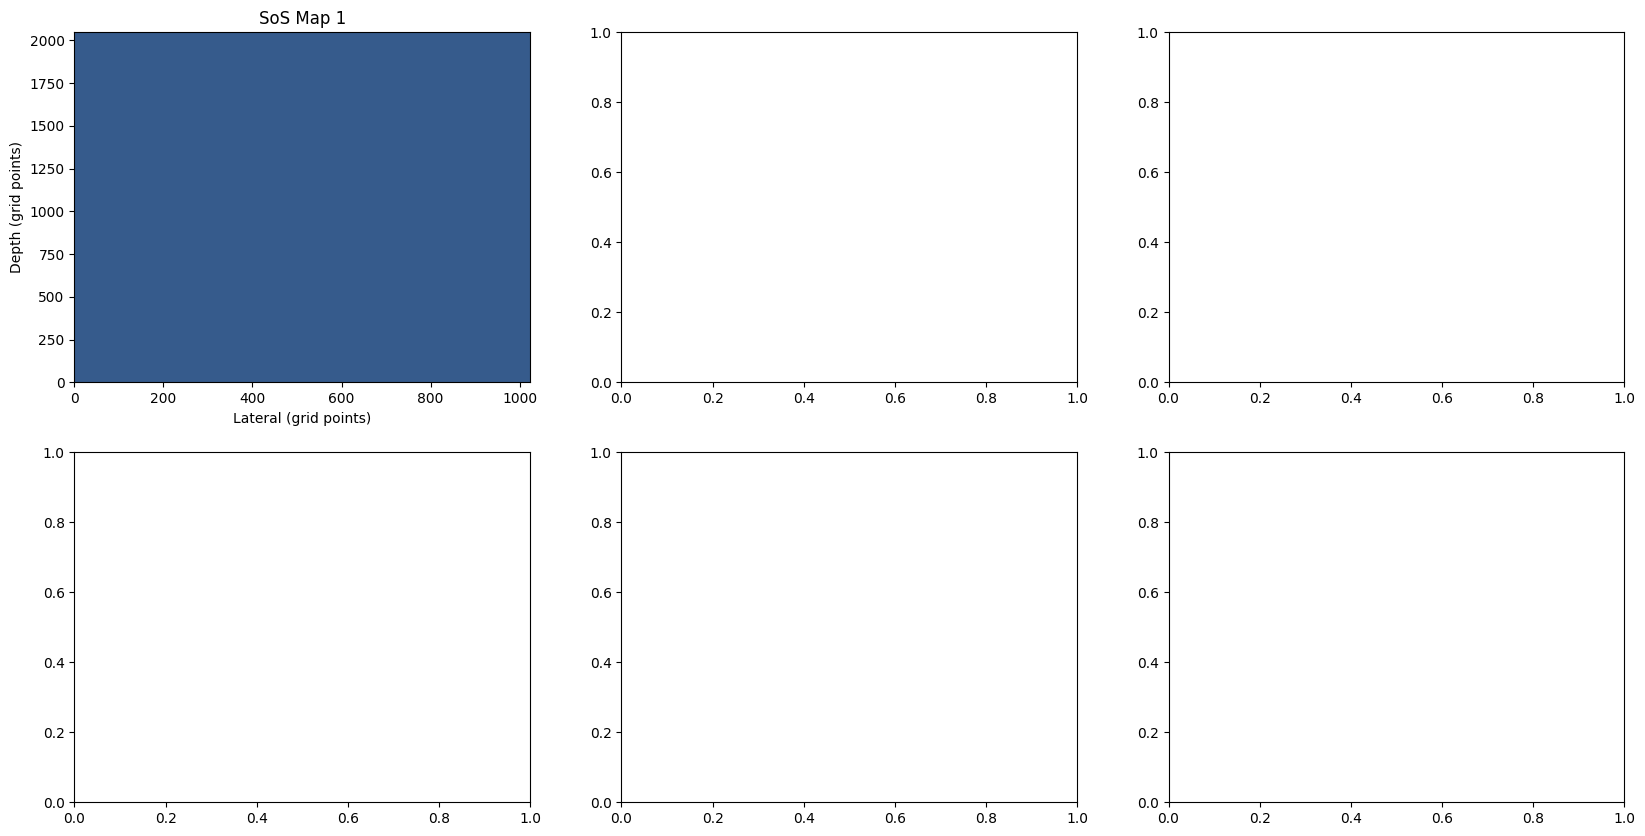

In [190]:
# Assuming num_data is the number of maps generated
fig, axes = plt.subplots(2, num_data, figsize=(20, 10))

for i in range(num_data):
    # --- Plot SoS Map ---
    # Fixed extent: [0, Nx, 0, Ny] ensures Depth 0 is at the top and Ny is at the bottom
    im1 = axes[0, i].imshow(sos_maps[i].T[::-1 , :], extent=[0, Nx, 0, Ny], cmap='viridis', aspect='auto', vmin=1300, vmax=2000)
    axes[0, i].set_title(f'SoS Map {i+1}')
    axes[0, i].set_xlabel('Lateral (grid points)')
    axes[0, i].set_ylabel('Depth (grid points)')

    # Corrected colorbar logic to use num_data index
    if i == num_data - 1:
        divider1 = make_axes_locatable(axes[0, i])
        cax1 = divider1.append_axes("right", size="5%", pad=0.1)
        fig.colorbar(im1, cax=cax1, label='SoS (m/s)')

    # --- Plot Density Map ---
    im2 = axes[1, i].imshow(den_maps[i].T[::-1 , :], extent=[0, Nx, 0, Ny], cmap='viridis', aspect='auto', vmin=900, vmax=1200)
    axes[1, i].set_title(f'Density Map {i+1}')
    axes[1, i].set_xlabel('Lateral (grid points)')
    axes[1, i].set_ylabel('Depth (grid points)')

    # Corrected colorbar logic for density row
    if i == num_data - 1:
        divider2 = make_axes_locatable(axes[1, i])
        cax2 = divider2.append_axes("right", size="5%", pad=0.1)
        fig.colorbar(im2, cax=cax2, label='Density (kg/m^3)')

plt.suptitle('Generated Breast Medium Maps: SoS & Density (Internal Porosity: 0.8)', fontsize=16)
plt.tight_layout(rect=[0, 0, 0.92, 0.95])
plt.show()

In [119]:
medium= []
for i in range(num_data):
    medium.append(kWaveMedium(sound_speed=sos_maps[i], density=den_maps[i]))

In [120]:
"""#defining the source and sensor (sonoghraphic setup) :
sensor_length = 30 #300 \mu m
pitch = 2 #30 \mu m
null_sider_areas = np.zeros((int(Nx/4), Ny), dtype=bool)
imaging_area = np.zeros((int(Nx/2) , Ny) , dtype=bool)
# Create repeating pattern: sensor_length x True + pitch x False = period 32
pattern_length = sensor_length + pitch
pattern = np.array([True]*sensor_length + [False]*pitch)

# Tile the pattern to cover the entire row
tiled_pattern = np.tile(pattern, Ny // pattern_length + 1)[:Ny]

# Apply pattern to the last row
imaging_area[:, -1] = tiled_pattern

#Generate the entire map
s_mask = np.vstack((null_sider_areas , imaging_area ,null_sider_areas))
#ploting the source pos in the map
plt.imshow(s_mask.T, cmap='gray')
plt.title('Source and Sensor Mask (Line Source at bottom Edge)')
plt.xlabel('Lateral (grid points)')
plt.ylabel('Depth (grid points)')
plt.show()

#defining the sensors :
sensor = kSensor(mask=s_mask, record=['p'])
"""

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
/var/folders/lj/v_nss_315119fjhxm19rw27r0000gn/T/ipykernel_2043/2393963102.py:2: SyntaxWarning: invalid escape sequence '\m'
  sensor_length = 30 #300 \mu m


"#defining the source and sensor (sonoghraphic setup) :\nsensor_length = 30 #300 \\mu m\npitch = 2 #30 \\mu m\nnull_sider_areas = np.zeros((int(Nx/4), Ny), dtype=bool)\nimaging_area = np.zeros((int(Nx/2) , Ny) , dtype=bool)\n# Create repeating pattern: sensor_length x True + pitch x False = period 32\npattern_length = sensor_length + pitch\npattern = np.array([True]*sensor_length + [False]*pitch)\n\n# Tile the pattern to cover the entire row\ntiled_pattern = np.tile(pattern, Ny // pattern_length + 1)[:Ny]\n\n# Apply pattern to the last row\nimaging_area[:, -1] = tiled_pattern\n\n#Generate the entire map\ns_mask = np.vstack((null_sider_areas , imaging_area ,null_sider_areas))\n#ploting the source pos in the map\nplt.imshow(s_mask.T, cmap='gray')\nplt.title('Source and Sensor Mask (Line Source at bottom Edge)')\nplt.xlabel('Lateral (grid points)')\nplt.ylabel('Depth (grid points)')\nplt.show()\n\n#defining the sensors :\nsensor = kSensor(mask=s_mask, record=['p'])\n"

In [121]:
def microns2grid(length):
    dx = Decimal('10e-6')
    return int(Decimal(str(length)) * Decimal('1e-6') / dx)


sensor_length = 300 #300 \mu m

dx = Decimal('10e-6')
int(Decimal(str(sensor_length)) * Decimal('1e-6') / dx)


30

In [122]:
numbers_of_sensors = 32
sensor_length = 30 #300 \mu m
pitch = 2 #30 \mu m
pattern_length = sensor_length + pitch
pattern = np.array([True]*sensor_length + [False]*pitch)

# Tile the pattern to cover the entire row
imaging_area_last_row = np.tile(pattern, numbers_of_sensors)

imaging_area = np.zeros((int(len(imaging_area_last_row)) , Ny) , dtype=bool)
imaging_area[:, -1] = imaging_area_last_row

sider_area = np.zeros((int((Nx-len(imaging_area_last_row))/2) , Ny) , dtype=bool)

s_mask = np.vstack((sider_area , imaging_area ,sider_area))
#defining the sensors :
sensor = kSensor(mask=s_mask, record=['p'])

### ploting the cropped map to check the source pos in the map

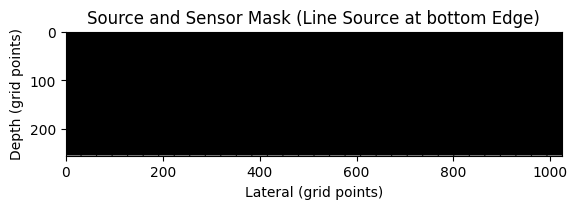

In [123]:
cropped_map = s_mask[Nx//2-Nx-len(imaging_area_last_row)//2:Nx//2+len(imaging_area_last_row)//2,Ny-len(imaging_area_last_row)//4:Ny]

#ploting the cropped map to check the source pos in the map
plt.imshow(cropped_map.T, cmap='gray')
plt.title('Source and Sensor Mask (Line Source at bottom Edge)')
plt.xlabel('Lateral (grid points)')
plt.ylabel('Depth (grid points)')
plt.show()

In [124]:
# 1. Create the base pulse (Tone Burst)
source = kSource()
amplitude  = 1
num_cycles = 3
f0 = 5e6 # 5 MHz center frequency
t_pulse = np.arange(0, num_cycles / f0, grid.dt)
# Gaussian windowed sine wave
pulse_signal = amplitude * np.sin(2 * np.pi * f0 * t_pulse) * np.exp(-((t_pulse - t_pulse[-1]/2)**2) / (2 * (t_pulse[-1]/6)**2))

# Pad with zeros to match simulation time
source_signal = np.zeros(grid.Nt)
source_signal[:len(pulse_signal)] = pulse_signal
# # Define focal point (e.g., 15mm deep in the center)
# x_focus = Nx*dx//2 + 15e-3
# y_focus = Ny*dy//2

# # Get coordinates of all active source elements
# element_idx = np.where(s_mask)
# x_coords = X[element_idx]
# y_coords = Y[element_idx]

# # Calculate distances to focus
# distances = np.sqrt((x_coords - x_focus)**2 + (y_coords - y_focus)**2)

# # Convert distance to time delays (relative to the furthest element)
# sound_speed = 1540 # [m/s]
# time_delays = (np.max(distances) - distances) / sound_speed
# delay_offsets = np.round(time_delays / grid.dt).astype(int)


source.p_mask = s_mask.astype(float)
# source.p should have shape (num_source_elements, num_time_steps)
num_source_elements = int(np.sum(s_mask))
source.p = np.tile(source_signal.reshape(1, -1), (num_source_elements, 1))  # set the source pressure signal


# #Create the Apodization Weights (Hann Window)
# # We normalize the position of elements from 0 to 1 across the width
# y_min, y_max = np.min(y_coords), np.max(y_coords)
# normalized_y = (y_coords - y_min) / (y_max - y_min)

# # Calculate Hann weights: 0.5 * (1 - cos(2 * pi * n))
# apodization_weights = 0.5 * (1 - np.cos(2 * np.pi * normalized_y))

# Apply weights to source.p
# Assuming you already have your source.p matrix (num_elements, num_time_steps)
# We multiply each row (element) by its corresponding weight
#source.p = source.p * apodization_weights.reshape(-1, 1)

In [125]:
from kwave.options.simulation_options import SimulationOptions
from kwave.options.simulation_execution_options import SimulationExecutionOptions
sim_options = SimulationOptions(pml_inside=False, save_to_disk=True)
#exec_options = SimulationExecutionOptions(is_gpu_simulation=True,backend = 'CUDA')
exec_options = SimulationExecutionOptions(is_gpu_simulation=False)
sensor_data = kspaceFirstOrder2D(grid, source, sensor, medium[2], simulation_options=sim_options, execution_options=exec_options)

<@beartype(kwave.kspaceFirstOrder2D.kspaceFirstOrder2D) at 0x11d203a60>:130: FutureWarning: kspaceFirstOrder2D is deprecated. Use kspaceFirstOrder() from kwave.kspaceFirstOrder instead. See kwave.compat.options_to_kwargs() for migrating options.


┌───────────────────────────────────────────────────────────────┐
│                   kspaceFirstOrder-OMP v1.3                   │
├───────────────────────────────────────────────────────────────┤
│ Reading simulation configuration:                        Done │
│ Number of CPU threads:                                      8 │
│ Processor name:                                      Apple M1 │
├───────────────────────────────────────────────────────────────┤
│                      Simulation details                       │
├───────────────────────────────────────────────────────────────┤
│ Domain dimensions:                                1064 x 2088 │
│ Medium type:                                               2D │
│ Simulation time steps:                                   3081 │
├───────────────────────────────────────────────────────────────┤
│                        Initialization                         │
├───────────────────────────────────────────────────────────────┤
│ Memory a

In [126]:
sensor_data['p'] != np.nan

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]], shape=(3081, 960))

In [127]:
sensor_data['p'] != np.nan

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]], shape=(3081, 960))

In [128]:
sensor_length = 30
sensor_elements_data = sensor_data['p']

# 1. Determine the number of complete channels we can form
num_channels = sensor_elements_data.shape[1] // sensor_length
valid_cols = num_channels * sensor_length

# 2. Slice to drop any trailing columns that don't make a full channel
trimmed_data = sensor_elements_data[:, :valid_cols]

# 3. Reshape and sum along the sensor_length dimension, then average
RF_data = trimmed_data.reshape(trimmed_data.shape[0], -1, sensor_length).sum(axis=2) / sensor_length

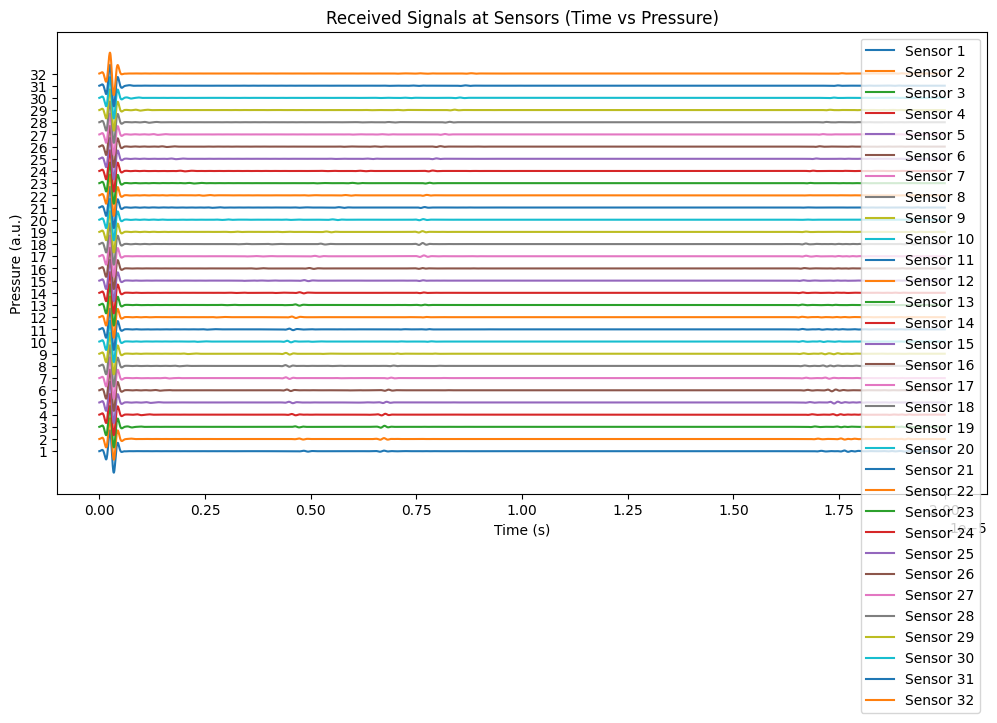

In [129]:
# sensor_data['p'][time,sensor_element] gives the pressure at a specific time and sensor element.
#ploting the received signals at the sensors in parallel channels :
"""plt.figure(figsize=(12, 6))
for i in range(RF_data.shape[1]):
    plt.plot(grid.t_array.flatten(), RF_data[:, i] + i*0.5, label=f'Sensor {i+1}')  # Offset each signal for visibility
plt.title('Received Signals at Sensors (Time vs Pressure)')
plt.xlabel('Time (s)')
plt.ylabel('Pressure (a.u.)')
plt.yticks(np.arange(0, RF_data.shape[1]*0.5, 0.5), [f'Sensor {i+1}' for i in range(RF_data.shape[1])])
plt.legend(loc='upper right')
plt.show()"""
plt.figure(figsize=(12, 6))
for i in range(RF_data.shape[1]):
    plt.plot(grid.t_array.flatten(), RF_data[:, i] + i*0.5,  label=f'Sensor {i+1}')  # Offset each signal for visibility
plt.title('Received Signals at Sensors (Time vs Pressure)')
plt.xlabel('Time (s)')
plt.ylabel('Pressure (a.u.)')
plt.yticks(np.arange(0, RF_data.shape[1]*0.5, 0.5), [i+1 for i in range(RF_data.shape[1])])
plt.legend(loc='upper right')
plt.show()